### Real Options Valuation for Pharmaceutical R&D

In [1]:
# This is a go/no-go switch code. This was inspired by the collaboratory work that I have done during my PhD albeit in energy
# What does Real Options mean in Pharma?
# Managemnet has the right to make strategic business decisions at specific milestones (decision tree)
# Option to abandon
# Option to defer/delay
# Option to expand/switch

n_simulations = 10000


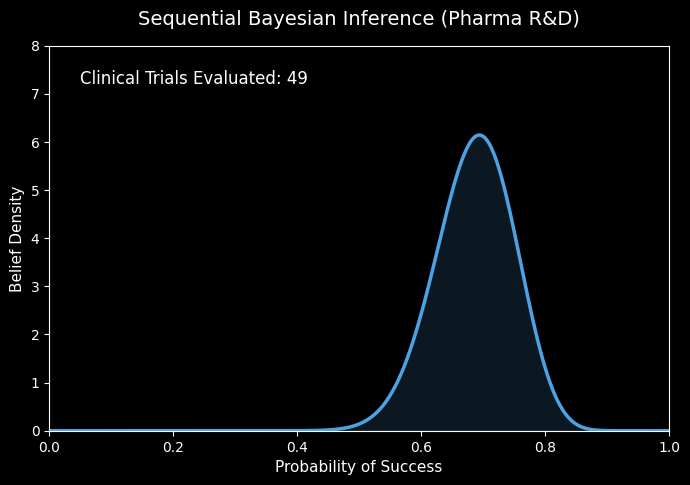

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from matplotlib.animation import FuncAnimation

# 1. Setup the dark-themed canvas
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(8, 5))

x = np.linspace(0, 1, 500)
true_probability = 0.75

# Initialize our parameters (flat prior)
a, b = 1, 1

# 2. Define the update function for the animation
def update(frame):
    global a, b
    
    # Clear the previous frame's lines to prevent ghosting
    ax.clear()
    
    # Set limits and styling again since ax.clear() resets them
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 8) # Keeps the vertical scale stable as the peak grows
    ax.set_title("Sequential Bayesian Inference (Pharma R&D)", fontsize=14, pad=15)
    ax.set_xlabel("Probability of Success", fontsize=11)
    ax.set_ylabel("Belief Density", fontsize=11)
    
    # Simulate a new data point (except on frame 0, which shows the initial prior)
    if frame > 0:
        outcome = np.random.binomial(1, true_probability)
        if outcome == 1:
            a += 1
        else:
            b += 1
            
    # Calculate the new probability curve
    y = beta.pdf(x, a, b)
    
    # Plot the updated curve
    ax.plot(x, y, color='#4ba3e3', lw=2.5)
    ax.fill_between(x, y, color='#4ba3e3', alpha=0.15)
    
    # Display the current data count
    ax.text(0.05, 0.90, f"Clinical Trials Evaluated: {frame}", 
            transform=ax.transAxes, fontsize=12, color='white', 
            bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

# 3. Create the animation object
# frames=50 means it will run the update function 50 times
ani = FuncAnimation(fig, update, frames=50, interval=200, repeat=False)

# 4. Save the file natively
# If you don't have ffmpeg or imagemagick, saving as a .gif might still fail.
# If it fails, comment out this line and use the HTML display method below.
ani.save('bayesian_update.gif', writer='pillow')

plt.show()